# Data Ingestion
Goal: Prepare the data for ingestion by neo4j

In [16]:
print("Importing packages...")
from py2neo import Graph, Node, Relationship
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Completed!")

Importing packages...
Completed!


## Dataset

In [48]:
print("Importing data...")
df = pd.read_csv("data/full_data_with_credits.csv")
# df = data.drop(data.columns[0], axis = 1)
df.head()

Importing data...


,id,title,overview,popularity,release_date,vote_average,vote_count,genre_ids,genres,actors,director
0,912649,Venom: The Last Dance,Eddie and Venom are on the run. Hunted by both...,3197.278,2024-10-22,6.5,763,"[878, 28, 12]","['Science Fiction', 'Action', 'Adventure']","['Tom Hardy', 'Chiwetel Ejiofor', 'Juno Temple...",Kelly Marcel
1,1034541,Terrifier 3,Five years after surviving Art the Clown's Hal...,2204.248,2024-10-09,6.9,1015,"[27, 53, 9648]","['Horror', 'Thriller', 'Mystery']","['Lauren LaVera', 'David Howard Thornton', 'Sa...",Damien Leone
2,1184918,The Wild Robot,"After a shipwreck, an intelligent robot called...",1868.856,2024-09-12,8.5,2908,"[16, 878, 10751]","['Animation', 'Science Fiction', 'Family']","[""Lupita Nyong'o"", 'Pedro Pascal', 'Kit Connor...",Chris Sanders
3,1118031,Apocalypse Z: The Beginning of the End,When a kind of rabies that transforms people i...,1861.349,2024-10-04,6.8,486,"[18, 28, 27]","['Drama', 'Action', 'Horror']","['Francisco Ortiz', 'José María Yázpik', 'Bert...",Carles Torrens
4,558449,Gladiator II,Years after witnessing the death of the revere...,1978.412,2024-11-13,6.8,409,"[28, 12, 18]","['Action', 'Adventure', 'Drama']","['Paul Mescal', 'Denzel Washington', 'Pedro Pa...",Ridley Scott


### Variables

- **id (int)**: Unique identifier for each movie.
- **title (str)**: The movie's title.
- **genre_ids (list[int])**: List of genre IDs associated with the movie (e.g., `[28, 12]` for Action and Adventure genres).
- **overview (str)**: Brief description or summary of the movie.
- **popularity (float)**: Popularity score based on TMDb's algorithm (typical range: `0.0` to `1000.0+`).
- **release_date (str)**: Release date of the movie in `YYYY-MM-DD` format.
- **vote_average (float)**: Average user rating on a scale from `0.0` to `10.0`.
- **vote_count (int)**: Number of user ratings received.


In [49]:
print(f"The shape of the dataset is {df.shape}")

The shape of the dataset is (2000, 11)


Popularity Summary Statistics:
count    2000.000000
mean       97.532353
std       154.918050
min        24.121000
25%        46.153500
50%        64.973500
75%        92.722500
max      3197.278000
Name: popularity, dtype: float64


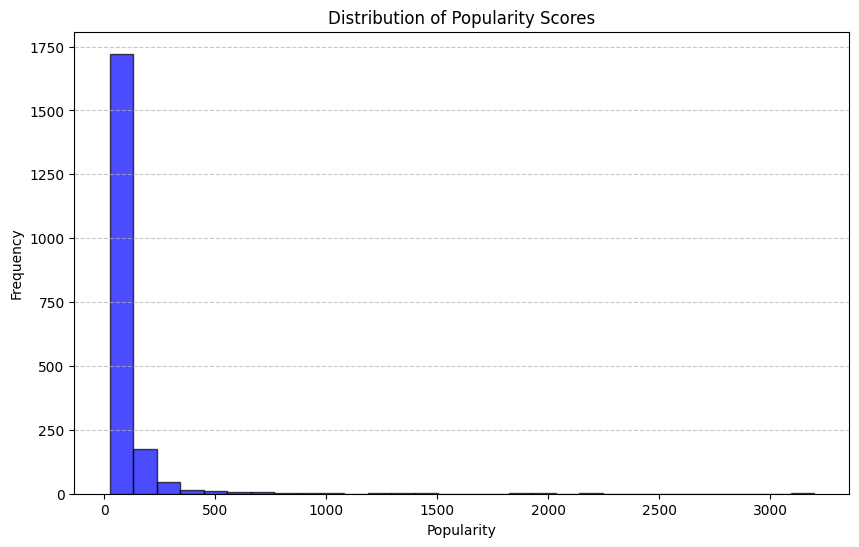

In [50]:
popularity_description = df['popularity'].describe()
print("Popularity Summary Statistics:")
print(popularity_description)

# Plotting the popularity distribution
plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title("Distribution of Popularity Scores")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


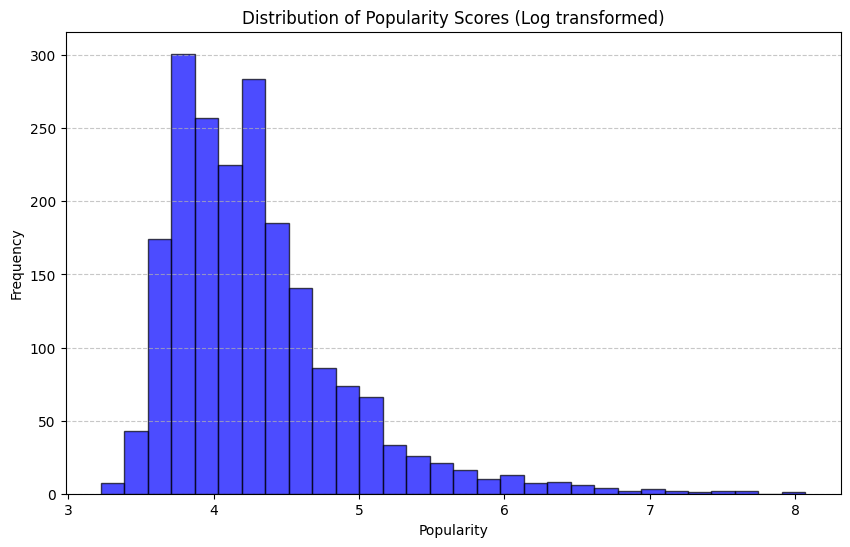

In [51]:
## given the high right-skew, we will log transform this data
df['log_popularity'] = np.log1p(df['popularity']) 

# Plotting the popularity distribution
plt.figure(figsize=(10, 6))
plt.hist(df['log_popularity'], bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title("Distribution of Popularity Scores (Log transformed)")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Popularity Bin Distribution (Log-Transformed with qcut):
popularity_bin
Very Low     334
Low          333
Moderate     333
High         333
Very High    333
Top          334
Name: count, dtype: int64


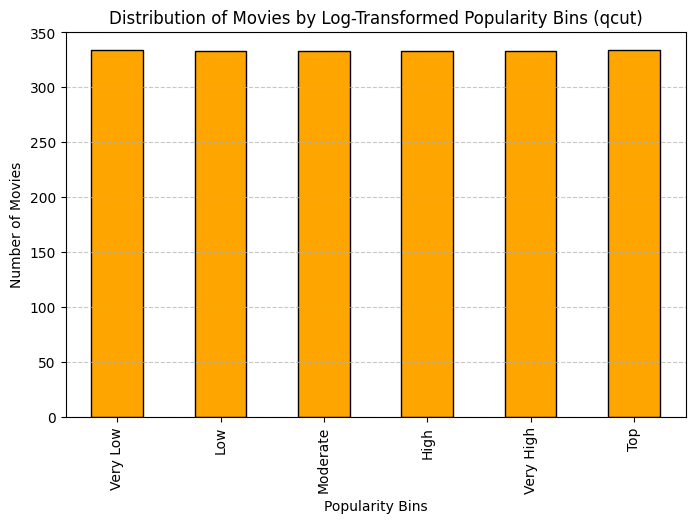

In [52]:
# Using log transformed values, categorize the values into bins
df['popularity_bin'] = pd.qcut(df['log_popularity'], q=6, labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High', 'Top'])

# Output bin distribution
popularity_bin_distribution = df['popularity_bin'].value_counts().sort_index()
print("\nPopularity Bin Distribution (Log-Transformed with qcut):")
print(popularity_bin_distribution)

# Plot the popularity bin distribution
plt.figure(figsize=(8, 5))
popularity_bin_distribution.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Distribution of Movies by Log-Transformed Popularity Bins (qcut)")
plt.xlabel("Popularity Bins")
plt.ylabel("Number of Movies")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Save the updated DataFrame
df.to_csv('data/full_data_binned_log.csv', index=False)

## Neo4j

### Setting up the Neo4j connection

In [53]:
load_dotenv()
NEO4J_URL = os.getenv("NEO4J_URL")  # Neo4j connection string (e.g., bolt://localhost:7687)
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME", "neo4j")  # Neo4j username
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")  # Neo4j password

print("Neo4j credentials retrieved")

Neo4j credentials retrieved


In [54]:
try:
    graph = Graph(NEO4J_URL, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
    print("Connected to Neo4j successfully!")
except Exception as e:
    print("Failed to connect:", e)

Connected to Neo4j successfully!


### Graphing the entities

In [55]:
from tqdm import tqdm  # Progress tracking
import ast             # For safer evaluation of stringified lists

# Load the dataset with log-transformed popularity bins
df = pd.read_csv("data/full_data_binned_log.csv")

# Connect to Neo4j
graph = Graph(NEO4J_URL, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))

# Clear existing data in Neo4j
graph.run("MATCH (n) DETACH DELETE n")

# Create nodes and relationships with progress tracking
for _, row in tqdm(df.iterrows(), total=len(df), desc="Ingesting data into Neo4j"):

    # Parse genres safely
    genres = ast.literal_eval(row["genres"]) if pd.notna(row["genres"]) else []
    
    # Create movie node 
    movie_node = Node(
        "Movie",
        id=row["id"],
        title=row["title"],
        release_year=int(row["release_date"][:4]) if pd.notna(row["release_date"]) else None,
        popularity=row["popularity"],
        popularity_bin=row["popularity_bin"],
        vote_average=row["vote_average"],
        vote_count=row["vote_count"]
    )
    graph.merge(movie_node, "Movie", "id")

    # Create genre nodes and relationships
    # For loop due to possibility of multiple genre vals
    for genre in genres:
        genre_node = Node("Genre", name=genre)
        graph.merge(genre_node, "Genre", "name")
        rel = Relationship(movie_node, "BELONGS_TO", genre_node)
        graph.merge(rel)

    # Create year node and relationship
    if movie_node["release_year"]:
        year_node = Node("Year", value=movie_node["release_year"])
        graph.merge(year_node, "Year", "value")
        rel = Relationship(movie_node, "RELEASED_IN", year_node)
        graph.merge(rel)

    # Create a popularity bin node and relationship
    if row["popularity_bin"]:
        pop_bin_node = Node("PopularityBin", name=row["popularity_bin"])
        graph.merge(pop_bin_node, "PopularityBin", "name")
        rel = Relationship(movie_node, "HAS_POPULARITY_BIN", pop_bin_node)
        graph.merge(rel)

    # Add directors (if available)
    if "director" in row and pd.notna(row["director"]):
        director_node = Node("Director", name=row["director"])
        graph.merge(director_node, "Director", "name")
        rel = Relationship(director_node, "DIRECTED", movie_node)
        graph.merge(rel)

    # Add actors (if available and stored as a list in the dataset)
    if "actors" in row and pd.notna(row["actors"]):
        actors = ast.literal_eval(row["actors"])
        for actor in actors:
            actor_node = Node("Actor", name=actor)
            graph.merge(actor_node, "Actor", "name")
            rel = Relationship(actor_node, "ACTED_IN", movie_node)
            graph.merge(rel)

print("Data ingestion completed with extended entities and relationships.")


Ingesting data into Neo4j: 100%|██████████| 2000/2000 [01:08<00:00, 29.20it/s]

Data ingestion completed with extended entities and relationships.


### Opening Neo4j

In [56]:
import webbrowser

def open_neo4j_browser(port):
    """
    Opens the Neo4j browser in the default web browser.

    Parameters:
    - port (int): The port number for the Neo4j HTTP interface (default: 7474).
    """
    neo4j_url = f"http://localhost:{port}/browser/"
    webbrowser.open(neo4j_url)

# Example usage
open_neo4j_browser(port = 7476)